### Step 1: Import required libraries

In [3]:
#Modules for EDA
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
plt.style.use('fivethirtyeight')

from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix

from tensorflow import keras

### Step 2: Load Data

In [4]:
import pandas as pd

heart_csv = pd.read_csv("heart.csv")
heart_csv.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
heart_csv = pd.read_csv('heart.csv')

### Step 3: Explore data

Find out how many rows and columns are there

In [6]:
heart_csv.shape

(918, 12)

Getting Basic information such as null count and data type for each column (feature)

In [7]:
heart_csv.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


Sum up counts of all columns with empty value

In [8]:
heart_csv.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Print out the first 5 rows of your dataset

In [9]:
heart_csv.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [10]:
# Example on how to drop columns
# heart_csv.drop('Unnamed: 0',axis=1,inplace=True)

Find out some basic stastistics of the dataset

In [11]:
heart_csv.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Replacing missing values with mean and observer

In [12]:
# heart_csv.fillna(heart_csv.mean(),inplace=True)
# heart_csv.describe()

### [Optional] Additional Codes to visualise our dataset

Basic plotting to find out the age group and count

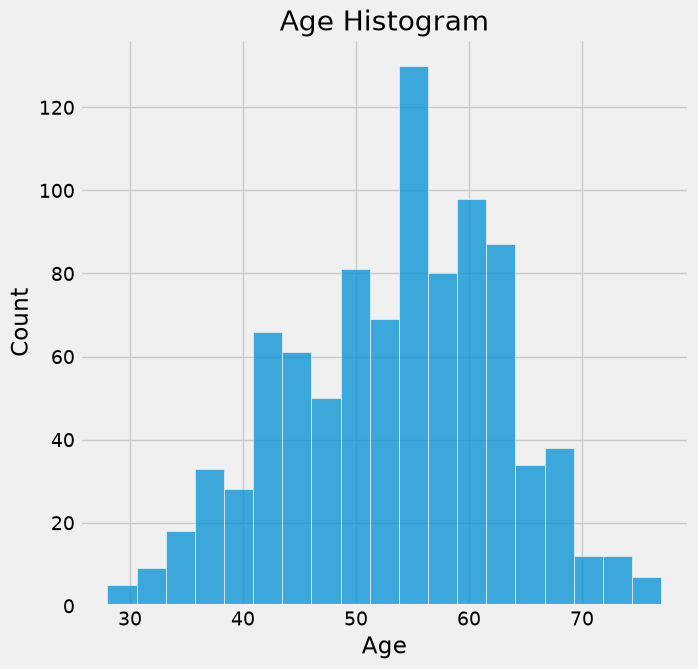

In [13]:
plt.figure(figsize=(7,7))
plt.title('Age Histogram')
sns.histplot(heart_csv['Age'])
plt.show()

Adding in additional information which includes the category

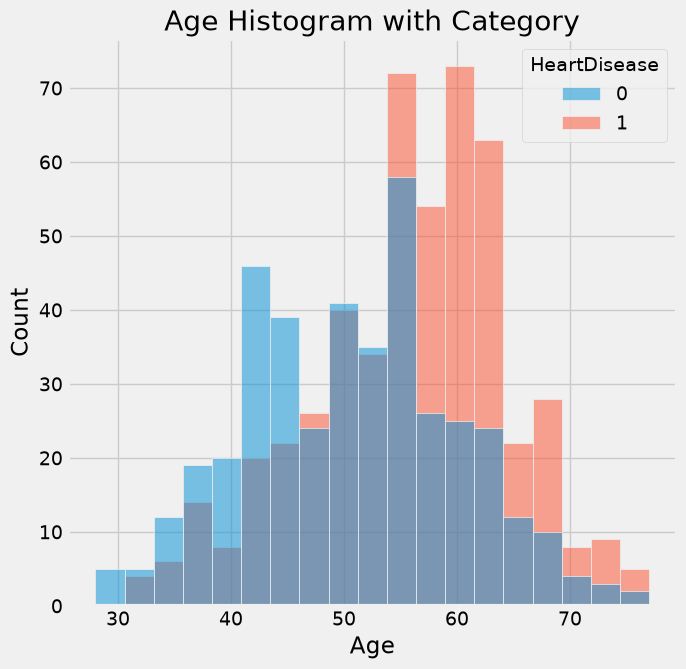

In [14]:
plt.figure(figsize=(7,7))
plt.title('Age Histogram with Category')
sns.histplot(heart_csv[['Age','HeartDisease']],x='Age',hue='HeartDisease')
plt.show()

A pie chart to show the percentage of the category

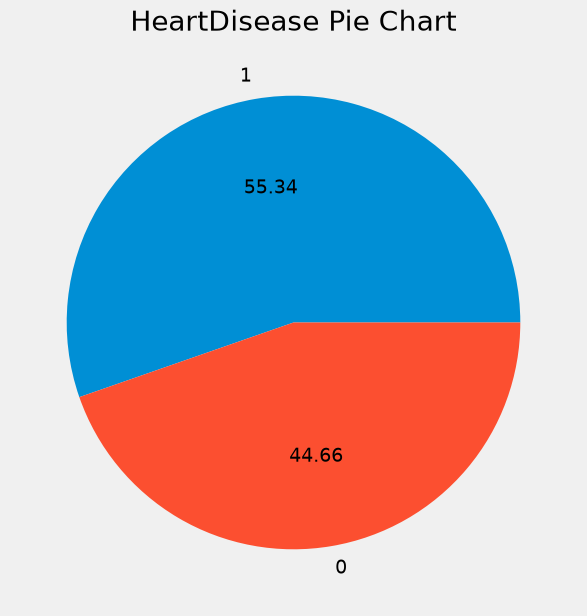

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [15]:
plt.figure(figsize=(7,7))
heart_csv['HeartDisease'].value_counts().plot(kind='pie',autopct='%.2f')
plt.title('HeartDisease Pie Chart')
plt.show()

heart_csv['HeartDisease'].value_counts()

In [16]:
heart_csv.HeartDisease.unique()

array([0, 1])

In [17]:
# heart disease column already in int, no need to convert
# replace_dict = dict()
# num_dict = dict()
# i=0
# for val in heart_csv['HeartDisease'].unique():
#     replace_dict[val] = i
#     num_dict[str(i)] = val
#     i += 1

In [18]:
# heart_csv['HeartDisease'].replace(replace_dict,inplace=True)
# heart_csv.HeartDisease.unique()

Converting Sex gender column to int from category (object)

In [19]:
heart_csv['Sex'].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

In [20]:
heart_csv['Sex'] = heart_csv['Sex'].replace({'M': 1, 'F': 0})
heart_csv['Sex'].value_counts()

Sex
1    725
0    193
Name: count, dtype: int64

converting chest pain type form object to int

In [21]:
heart_csv['ChestPainType'].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

In [22]:
heart_csv['ChestPainType'] = heart_csv['ChestPainType'].replace({'ASY': 0, 'NAP': 1, 'ATA': 2, 'TA': 3})
heart_csv['ChestPainType'].value_counts()

ChestPainType
0    496
1    203
2    173
3     46
Name: count, dtype: int64

Converting RestingECG from object to int

In [23]:
heart_csv['RestingECG'].value_counts()

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

In [24]:
heart_csv['RestingECG'] = heart_csv['RestingECG'].replace({'Normal': 0, 'LVH': 1, 'ST': 2})
heart_csv['RestingECG'].value_counts()

RestingECG
0    552
1    188
2    178
Name: count, dtype: int64

Converting ExerciseAngina from object to int

In [25]:
heart_csv['ExerciseAngina'].value_counts()

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

In [26]:
heart_csv['ExerciseAngina'] = heart_csv['ExerciseAngina'].replace({'N': 0, 'Y': 1})
heart_csv['ExerciseAngina'].value_counts()

ExerciseAngina
0    547
1    371
Name: count, dtype: int64

Converting ST_Slope from object to int

In [27]:
heart_csv['ST_Slope'].value_counts()

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

In [28]:
heart_csv['ST_Slope'] = heart_csv['ST_Slope'].replace({'Flat': 1, 'Up': 2, 'Down': 0})
heart_csv['ST_Slope'].value_counts()

ST_Slope
1    460
2    395
0     63
Name: count, dtype: int64

In [29]:
# check data type again
heart_csv.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


Split data into X and Y (Features and label)


In [30]:
x,y = heart_csv.drop('HeartDisease',axis=1),heart_csv['HeartDisease']

In [31]:
smote = SMOTE()
x,y = smote.fit_resample(x,y)

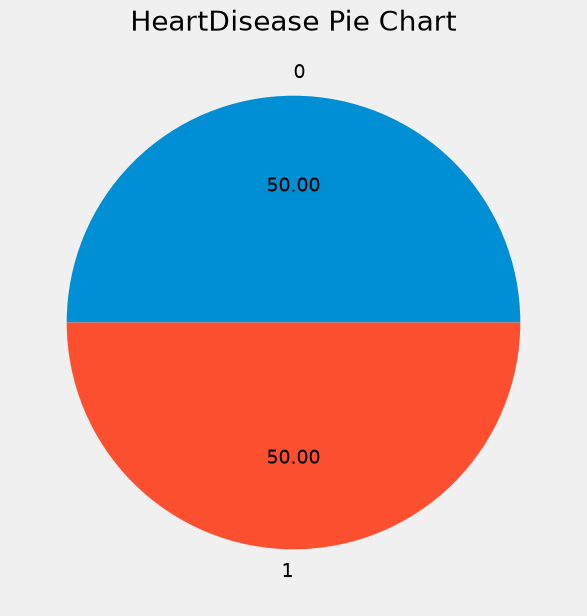

HeartDisease
0    508
1    508
Name: count, dtype: int64

In [32]:
plt.figure(figsize=(7,7))
y.value_counts().plot(kind='pie',autopct='%.2f')
plt.title('HeartDisease Pie Chart')
plt.show()
y.value_counts()

In [33]:
heart_csv.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,2,140,289,0,0,172,0,0.0,2,0
1,49,0,1,160,180,0,0,156,0,1.0,1,1
2,37,1,2,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,0,108,1,1.5,1,1
4,54,1,1,150,195,0,0,122,0,0.0,2,0


In [34]:
cols_to_scale = x.drop(['Sex', "ExerciseAngina"],axis=1).columns
cols_to_scale


Index(['Age', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'Oldpeak', 'ST_Slope'],
      dtype='str')

In [35]:
print(x.columns.tolist())

['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']


In [36]:
cols_to_scale = x.drop(['Sex', "ExerciseAngina"],axis=1).columns
cols_to_scale

Index(['Age', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'Oldpeak', 'ST_Slope'],
      dtype='str')

In [37]:
scale = MinMaxScaler()
scaled = scale.fit_transform(x[cols_to_scale])

In [38]:
i = 0
for col in cols_to_scale:
    x[col] = scaled[:,i]
    i += 1

In [39]:
# print to check results after scaling
x.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,0.244898,1.0,0.666667,0.70,0.479270,0.0,0.0,0.788732,0.0,0.295455,1.0
1,0.428571,0.0,0.333333,0.80,0.298507,0.0,0.0,0.676056,0.0,0.409091,0.5
2,0.183673,1.0,0.666667,0.65,0.469320,0.0,1.0,0.267606,0.0,0.295455,1.0
3,0.408163,0.0,0.000000,0.69,0.354892,0.0,0.0,0.338028,1.0,0.465909,0.5
4,0.530612,1.0,0.333333,0.75,0.323383,0.0,0.0,0.436620,0.0,0.295455,1.0


### Step 4: Split Data into Train and Test

In [40]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((711, 11), (305, 11), (711,), (305,))

### Step 5: Creating and Training Model

In [41]:
model = keras.Sequential([
    keras.layers.Dense(11, input_shape=(x_train.shape[1],), activation='relu'),
    keras.layers.Dense(2,activation='softmax')
])

model.compile(
    optimizer='adam',
    metrics=['accuracy'],
    loss='sparse_categorical_crossentropy'
)

/Users/emilyk/Desktop/Heart Disease ML/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
import tensorflow as tf
model.fit(x_train,y_train,epochs=1000)

Epoch 1/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 663us/step - accuracy: 0.3038 - loss: 0.9055
Epoch 2/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 563us/step - accuracy: 0.3601 - loss: 0.8417
Epoch 3/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step - accuracy: 0.4121 - loss: 0.7826
Epoch 4/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step - accuracy: 0.4585 - loss: 0.7269
Epoch 5/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 543us/step - accuracy: 0.4740 - loss: 0.6771
Epoch 6/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step - accuracy: 0.5907 - loss: 0.6257
Epoch 7/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step - accuracy: 0.7511 - loss: 0.5774
Epoch 8/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step - accuracy: 0.7918 - loss: 0.5410
Epoch 9/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 556us/step - accuracy: 0.8003 - loss: 0.5134
Epoch 10/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step - accuracy: 0.8045 - loss: 0.4933
Epoch 11/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 526us/step - accuracy: 0.8045 - loss: 0.4766
Epoch 12/1000
23/23 ━━━━━━━━━━

### Step 6: Evaluate Model

In [43]:
model.evaluate(x_test,y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 923us/step - accuracy: 0.8787 - loss: 0.3464


[0.34638500213623047, 0.8786885142326355]

### Step 7: Prediction function

In [44]:
import numpy as np

def predict(model,x):
    pred = model.predict(x)
    pred_test = np.array([np.argmax(pred[i]) for i in range(len(pred))])
    return pred_test

def plot_actual_vs_predicted(y_true,y_pred,title):
    cm = confusion_matrix(y_true,y_pred)
    plt.figure(figsize=(7,7))
    sns.heatmap(cm/np.sum(cm),annot=True,fmt='.2%',
                xticklabels=heart_csv["HeartDisease"].unique(),yticklabels=heart_csv["HeartDisease"].unique())
    plt.title(title)
    plt.show()
    print("Classification Report")
    print(classification_report(y_true,y_pred))

Test Data Predictions

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


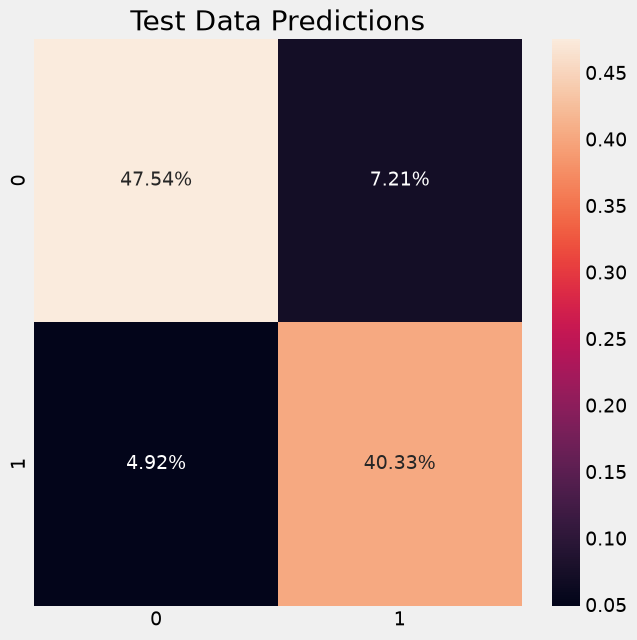

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.87      0.89       167
           1       0.85      0.89      0.87       138

    accuracy                           0.88       305
   macro avg       0.88      0.88      0.88       305
weighted avg       0.88      0.88      0.88       305



In [45]:
y_test_pred = predict(model,x_test)
plot_actual_vs_predicted(y_test,y_test_pred,"Test Data Predictions")

Train Data Predictions

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 403us/step


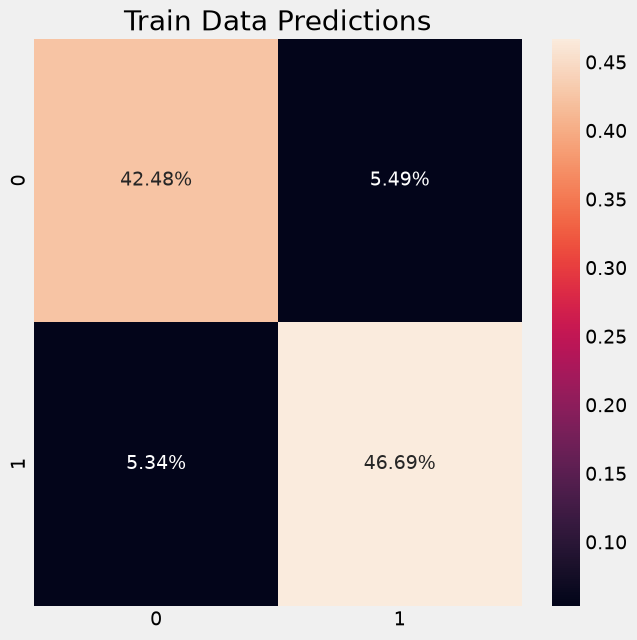

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       341
           1       0.89      0.90      0.90       370

    accuracy                           0.89       711
   macro avg       0.89      0.89      0.89       711
weighted avg       0.89      0.89      0.89       711



In [46]:
y_train_pred = predict(model,x_train)
plot_actual_vs_predicted(y_train,y_train_pred,"Train Data Predictions")

In [47]:
model.save("heart_disease.h5")
print("Saved model to disk")

Saved model to disk


In [48]:
y_test.head()

491    1
515    0
784    1
68     1
120    1
Name: HeartDisease, dtype: int64

In [49]:
x_test.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
491,0.959184,1.0,0.000000,0.850,0.336650,1.0,1.0,0.338028,0.0,0.295455,0.5
515,0.714286,1.0,0.333333,0.650,0.000000,1.0,1.0,0.704225,0.0,0.636364,0.5
784,0.755102,1.0,1.000000,0.690,0.467662,1.0,0.5,0.802817,0.0,0.454545,0.5
68,0.489796,1.0,0.000000,0.800,0.407960,0.0,1.0,0.154930,1.0,0.750000,0.5
120,0.387755,0.0,0.333333,0.675,0.411277,1.0,0.0,0.774648,0.0,0.295455,0.5


In [50]:
model.save("heart_disease_model.h5")

In [52]:
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scale, f)